In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
# COLLECT THE DATA

In [8]:
#3
df = pd.DataFrame(pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv"))

In [13]:
#4
print(df.shape)
#There are 100 rows and 6 columns
print(df.head())
print(df.tail())
print(df.columns)
#column names: 'x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850
Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


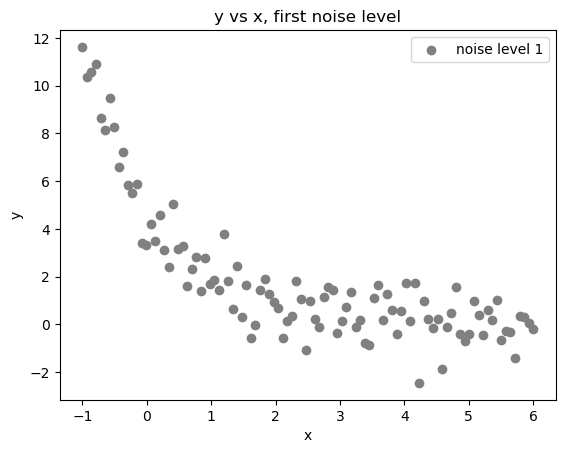

In [38]:
#5
x= df["x"]
y_noise_1= df["y_noise_1"]
plt.figure()
plt.scatter(x, y_noise_1, color = "gray", label= "noise level 1")
plt.title("y vs x, first noise level")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
# FIT THE DATA

In [36]:
#1: Define the model
def model(x, A, k):
    return A* np.exp(-k * x)

In [39]:
#2: fit model to to y noise 1 data
p0 = [1,1] # initial guess
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0) #curve fit

In [40]:
#3: Extracting best fit parameters:
A_fit, k_fit = popt

In [42]:
#4: printing fitted model w/ two decimal places
print(f"Fit: y = {A_fit}* e^(-{k_fit:.2f}*x)")

Fit: y = 4.714813880431482* e^(-0.92*x)


In [96]:
#5: calculate reduced chi-squared
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2= np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2/dof

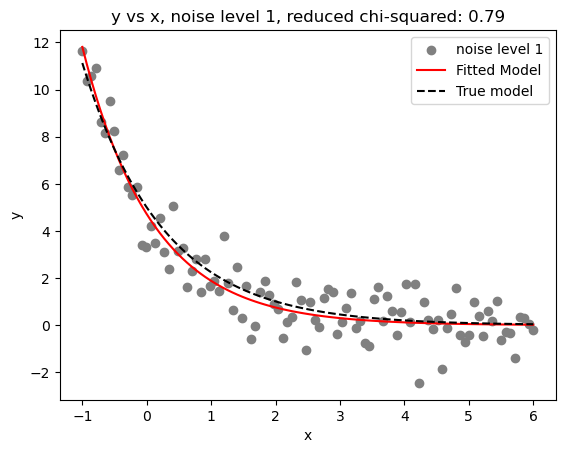

In [49]:
#6 Plotting result
plt.figure()
plt.scatter(x, y_noise_1, color = "gray", label= "noise level 1") #noisy data
plt.plot(x, A_fit* np.exp(-k_fit * x), color = "red", label = "Fitted Model") #fitted model
plt.plot(x, model(x,5,0.8), color = "black", linestyle = "--", label = "True model")
plt.title(f"y vs x, noise level 1, reduced chi-squared: {chi2_reduced:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
#COMPARE DIFFFERENT NOISE LEVELS

In [91]:
#1
def fit_model(x,y):
    p0 = [1,1] # initial guess
    popt, pcov = curve_fit(model, x, y, p0=p0) #curve fit
    A_fit, k_fit = popt
    
    residuals = y - model(x, A_fit, k_fit)
    chi2= np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2/dof
    
    return A_fit, k_fit, chi2_reduced

print(fit_model(df['x'], df["y_noise_2"]))

(np.float64(5.063888699407368), np.float64(0.7303962598356716), np.float64(3.6493823840389004))


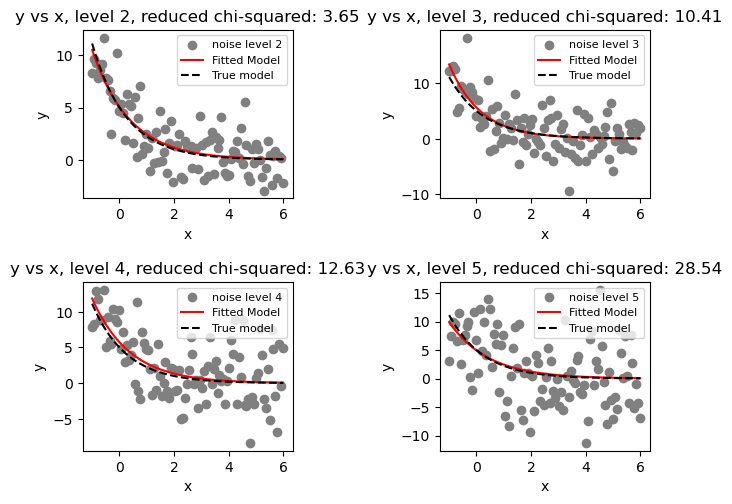

In [107]:
#2
fig, axes = plt.subplots(2, 2)
plt.tight_layout()
fig.subplots_adjust(hspace=0.5)
fig.subplots_adjust(wspace=0.7)
#3
for index, noise_level in enumerate(df.columns[2:6]):
    A_fit, k_fit, chi2_reduced= fit_model(x, df[noise_level])
    axes[index//2][index%2].scatter(x, df[noise_level], color = "gray", label= f"noise level {index+2}")
    axes[index//2][index%2].plot(x, A_fit* np.exp(-k_fit * x), color = "red", label = "Fitted Model")
    axes[index//2][index%2].plot(x, model(x,5,0.8), color = "black", linestyle = "--", label = "True model")
    axes[index//2][index%2].set_title(f"y vs x, level {index+2}, reduced chi-squared: {chi2_reduced:.2f}")
    axes[index//2][index%2].legend(fontsize=8)
    axes[index//2][index%2].set_xlabel("x")
    axes[index//2][index%2].set_ylabel("y")

    

In [ ]:
#4
#As the noise level increases, the accuracy of the fitted model decreases, while the True model stays constant.
#This is because, with higher noise level, the fitted model has to account for more random fluctuations. However, no matter how scattered the data becomes, the true model will not change.

#As the noise level increases, the reduced chi-squared increases significantly. 
#This is because as the data becomes noiser, and the fitted model becomes less accurate, reduced chi-squared should increase further from one (since a reduced chi squared value close to indicates a good fit). 

In [ ]:
# SAVE YOUR RESULTS

In [116]:
#1
noise_level_list = []
A_fit_list = []
k_fit_list = []
chi2_reduced_list = []

for index, noise_level in enumerate(df.columns[1:6]):
    A_fit, k_fit, chi2_reduced= fit_model(x, df[noise_level])
    noise_level_list.append(noise_level)
    A_fit_list.append(A_fit)
    k_fit_list.append(k_fit)
    chi2_reduced_list.append(chi2_reduced)
    
    
data = { 
    "Noise_level": noise_level_list,
    "A fit": A_fit_list,
    "k fit" : k_fit_list,
    "Reduced chi squared" : chi2_reduced_list}

df1 = pd.DataFrame(data)
df1

,Noise_level,A fit,k fit,Reduced chi squared
0,y_noise_1,4.714814,0.918308,0.790673
1,y_noise_2,5.063889,0.730396,3.649382
2,y_noise_3,5.609396,0.870372,10.410207
3,y_noise_4,5.738727,0.725965,12.626832
4,y_noise_5,4.943458,0.695012,28.538124


In [117]:
#2
df1.to_csv("noisy_paramters.csv", index = False)